Total training points: 34025
Polynomial Degree: 12

ERROR METRICS
MAE  : 1.8163 °C
RMSE : 2.2873 °C
R² Score : 0.999966


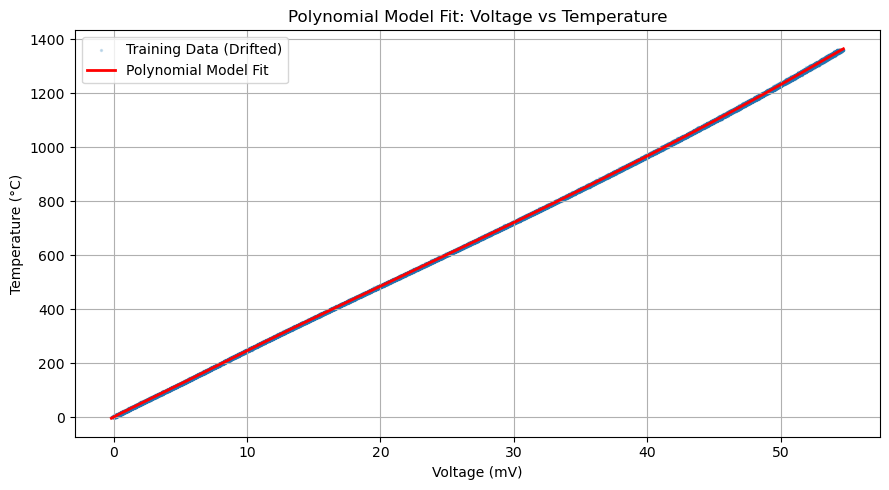

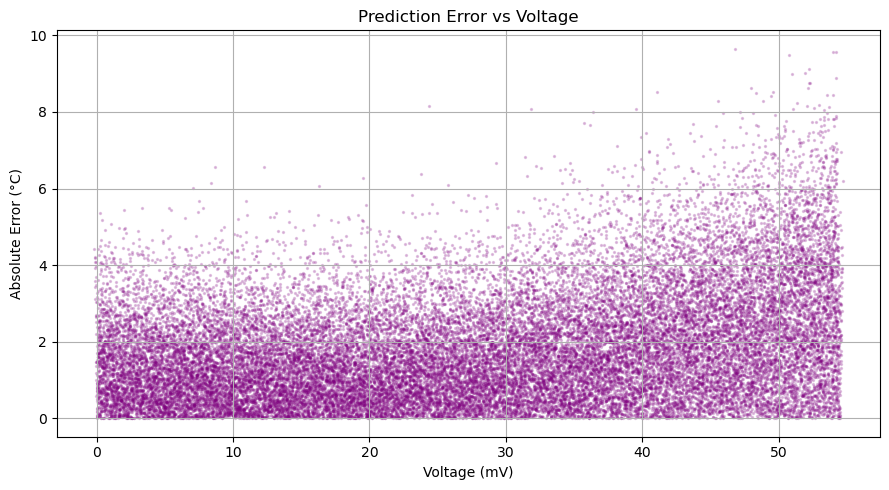


MANUAL CHECK (Voltage → Temperature)
-------------------------------------------------------
0.039 mV → Predicted: 0.95°C | Actual: 1°C | Error: 0.05°C
0.397 mV → Predicted: 10.14°C | Actual: 10°C | Error: 0.14°C
6.299 mV → Predicted: 154.05°C | Actual: 154°C | Error: 0.05°C
48.838 mV → Predicted: 1199.84°C | Actual: 1200°C | Error: 0.16°C
43.518 mV → Predicted: 1057.95°C | Actual: 1058°C | Error: 0.05°C
45.119 mV → Predicted: 1099.96°C | Actual: 1100°C | Error: 0.04°C
5.123 mV → Predicted: 124.92°C | Actual: 125°C | Error: 0.08°C
ADC=6 | Voltage=0.000 mV | Predicted Temp=-0.07 °C | Reference Temp=0.00 °C | Error=0.07 °C
ADC=5 | Voltage=-0.054 mV | Predicted Temp=-1.47 °C | Reference Temp=0.00 °C | Error=1.47 °C
ADC=6 | Voltage=0.000 mV | Predicted Temp=-0.07 °C | Reference Temp=0.00 °C | Error=0.07 °C
ADC=5 | Voltage=-0.054 mV | Predicted Temp=-1.47 °C | Reference Temp=0.00 °C | Error=1.47 °C
ADC=6 | Voltage=0.000 mV | Predicted Temp=-0.07 °C | Reference Temp=0.00 °C | Error=0.07 °C


KeyboardInterrupt: 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------------
# 1. Load dataset 
# -----------------------------
data = pd.read_csv("NIST Thermocouple Type K 2.csv")

temperature   = data["Temperature"].values
ideal_voltage = data["Voltage"].values

# -----------------------------
# 2. Generate multiple drifted copies
# So model learns: any drifted voltage → correct temperature
# -----------------------------
np.random.seed(42)

N = 25  # 25 drifted versions per data point → 1361 × 25 = 34,025 training points

X_augmented = []
y_augmented = []

for i in range(N):
    gain_drift   = np.random.uniform(-0.005, 0.005)   # ±0.5% random gain drift
    offset_drift = np.random.uniform(-0.10,  0.10)    # ±0.1mV random offset
    noise        = np.random.normal(0, 0.05, size=len(ideal_voltage))  # EMI noise

    drifted = ideal_voltage * (1 + gain_drift) + offset_drift + noise

    X_augmented.append(drifted)
    y_augmented.append(temperature)

X_augmented = np.concatenate(X_augmented).reshape(-1, 1)
y_augmented = np.concatenate(y_augmented)

print(f"Total training points: {len(X_augmented)}")

# -----------------------------
# 3. Scale + Polynomial Features
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_augmented)

degree = 12
poly   = PolynomialFeatures(degree=degree)
X_poly = poly.fit_transform(X_scaled)

# -----------------------------
# 4. Train model on ALL data
# -----------------------------
model = LinearRegression()
model.fit(X_poly, y_augmented)

print(f"Polynomial Degree: {degree}")

# -----------------------------
# 5. Error Metrics
# -----------------------------
y_pred         = model.predict(X_poly)
absolute_error = np.abs(y_augmented - y_pred)

mae  = mean_absolute_error(y_augmented, y_pred)
rmse = np.sqrt(mean_squared_error(y_augmented, y_pred))
r2 = r2_score(y_augmented, y_pred)

print("\nERROR METRICS")
print(f"MAE  : {mae:.4f} °C")
print(f"RMSE : {rmse:.4f} °C")
print(f"R² Score : {r2:.6f}")

# -----------------------------
# 6. Model Fit Graph
# -----------------------------
sort_idx      = np.argsort(X_augmented.flatten())
X_sorted      = X_augmented[sort_idx]
X_sorted_poly = poly.transform(scaler.transform(X_sorted))
y_sorted_pred = model.predict(X_sorted_poly)

plt.figure(figsize=(9, 5))
plt.scatter(X_augmented, y_augmented, s=2, alpha=0.2, label="Training Data (Drifted)")
plt.plot(X_sorted, y_sorted_pred, color="red", linewidth=2, label="Polynomial Model Fit")
plt.xlabel("Voltage (mV)")
plt.ylabel("Temperature (°C)")
plt.title("Polynomial Model Fit: Voltage vs Temperature")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# 7. Error Graph
# -----------------------------
plt.figure(figsize=(9, 5))
plt.scatter(X_augmented, absolute_error, s=2, alpha=0.2, color="purple")
plt.xlabel("Voltage (mV)")
plt.ylabel("Absolute Error (°C)")
plt.title("Prediction Error vs Voltage")
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# 8. Manual Check
# -----------------------------
print("\nMANUAL CHECK (Voltage → Temperature)")
print("-" * 55)

manual_voltages = np.array([
    [0.039],     # ~1°C
    [0.397],     # ~10°C
    [6.299],     # ~154°C
    [48.838],    # ~1200°C
    [43.518],    # ~1058°C
    [45.119],    # ~1100°C
    [5.123]      # ~125°C 
])

actual_temps = [1, 10, 154, 1200, 1058, 1100, 125]

manual_scaled  = scaler.transform(manual_voltages)
manual_poly    = poly.transform(manual_scaled)
predicted_temp = model.predict(manual_poly)

for v, p, a in zip(manual_voltages.flatten(), predicted_temp, actual_temps):
    print(f"{v:.3f} mV → Predicted: {p:.2f}°C | Actual: {a}°C | Error: {abs(p-a):.2f}°C")


